# Logistic Regression: Training and Evaluation

This notebook provides a structured introduction to training and evaluating a **Logistic Regression** model.

The notebook is divided into two main parts:

### Part A — Guided Workflow
You will follow a complete machine learning workflow:

1. Understand the classification problem.
2. Create and inspect the dataset.
3. Define the features and target.
4. Split the data into training and testing sets.
5. Build a preprocessing and modeling pipeline.
6. Train the model.
7. Generate class predictions and probability estimates.
8. Evaluate the model using classification metrics.
9. Interpret coefficients and decision thresholds.

### Part B — Practice Exercises
The second half applies the same concepts through independent exercises.

---

## Learning Outcomes

By the end of this lab, you should be able to:

- Identify a binary classification problem.
- Explain the difference between class labels and probability estimates.
- Separate the feature matrix `X` from the target vector `y`.
- Split data into training and testing sets.
- Train a Logistic Regression model using `fit()`.
- Generate class predictions using `predict()`.
- Generate probability estimates using `predict_proba()`.
- Interpret the intercept and coefficients.
- Evaluate a classifier using Accuracy, Precision, Recall, F1-score, Confusion Matrix, and ROC-AUC.
- Change the classification threshold and explain its effect.

## Notebook Structure

### Part A — Guided Workflow
1. Logistic Regression Overview  
2. Import Libraries  
3. Create the Dataset  
4. Inspect the Dataset  
5. Visualize the Classes  
6. Define `X` and `y`  
7. Split the Data  
8. Build the Pipeline  
9. Train the Model  
10. Predict Classes  
11. Predict Probabilities  
12. Apply a Decision Threshold  
13. Evaluate the Model  
14. Interpret the Confusion Matrix  
15. Plot the ROC Curve  
16. Interpret Coefficients  
17. Predict a New Example  
18. Compare Different Thresholds  

### Part B — Practice Exercises
Exercises 1–12, including a final classification challenge.

---
# Part A — Guided Workflow

Follow the cells in order. Read the explanation before running each code cell.

## 1. Logistic Regression in One Picture

Logistic Regression follows this sequence:

$$
X \rightarrow z = \theta_0 + \theta_1x_1 + \cdots + \theta_nx_n
\rightarrow \sigma(z)
\rightarrow P(y=1 \mid X)
\rightarrow \text{Class 0 or Class 1}
$$

The sigmoid function is:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

- `fit()` learns the intercept and coefficients.
- `predict_proba()` returns probability estimates.
- `predict()` converts probabilities into final class labels.

## 2. Import the Required Libraries

In [1]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Make random results reproducible
RANDOM_STATE = 42

## 3. Create an Extended Teaching Dataset

The lecture used a small **student pass prediction** example with:

- `study_hours`
- `attendance`
- `pass`

The dataset below is an expanded synthetic teaching dataset so that we can perform a fair train/test split.

> `pass = 1` means the student passed.  
> `pass = 0` means the student failed.

In [2]:
# Create a reproducible synthetic dataset
rng = np.random.default_rng(RANDOM_STATE)

n_students = 160

study_hours = rng.uniform(0.5, 10.0, n_students)
attendance = rng.uniform(45, 100, n_students)

# Create an underlying probability of passing.
# Higher study hours and attendance increase the probability.
z = -8.0 + 0.85 * study_hours + 0.075 * attendance
probability_of_pass = 1 / (1 + np.exp(-z))

# Generate binary labels from the probabilities
passed = rng.binomial(1, probability_of_pass)

df = pd.DataFrame({
    "study_hours": np.round(study_hours, 1),
    "attendance": np.round(attendance, 1),
    "pass": passed
})

df.head(10)

,study_hours,attendance,pass
0,7.9,50.9,1
1,4.7,95.4,1
2,8.7,57.7,1
3,7.1,47.1,1
4,1.4,75.5,1
5,9.8,65.4,1
6,7.7,90.6,1
7,8.0,89.5,1
8,1.7,62.4,0
9,4.8,97.4,1


### Inspect the Dataset

In [3]:
# Display the dataset dimensions
print("Dataset shape:", df.shape)

# Display column data types
print("\nData types:")
print(df.dtypes)

# Check missing values
print("\nMissing values:")
print(df.isna().sum())

# Check class distribution
print("\nClass distribution:")
print(df["pass"].value_counts().sort_index())

Dataset shape: (160, 3)

Data types:
study_hours    float64
attendance     float64
pass             int64
dtype: object

Missing values:
study_hours    0
attendance     0
pass           0
dtype: int64

Class distribution:
pass
0     52
1    108
Name: count, dtype: int64


### Why do we inspect the class distribution?

A classification model may look accurate even when one class dominates the dataset.

For example, if 95% of students passed, a weak model could predict `pass = 1` for everyone and still obtain 95% Accuracy. Therefore, we inspect both classes before training.

## 4. Visualize the Two Classes

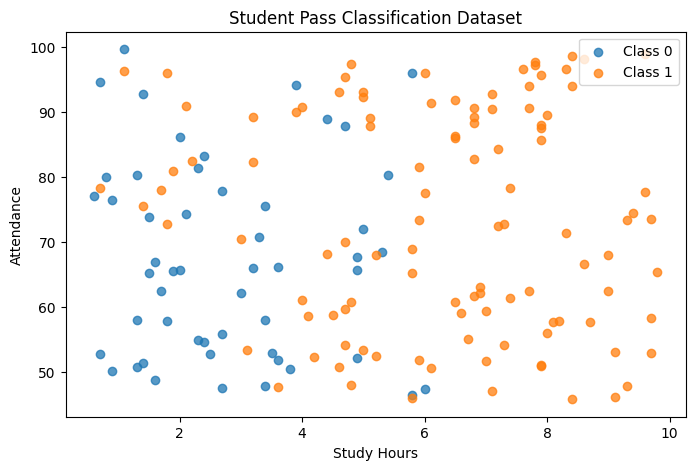

In [4]:
plt.figure(figsize=(8, 5))

# Plot each class separately using default matplotlib colors
for class_value in sorted(df["pass"].unique()):
    subset = df[df["pass"] == class_value]
    plt.scatter(
        subset["study_hours"],
        subset["attendance"],
        label=f"Class {class_value}",
        alpha=0.75
    )

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Pass Classification Dataset")
plt.legend()
plt.show()

## 5. Define the Features `X` and the Target `y`

The model uses the features to predict the target.

- `X`: input features.
- `y`: correct binary class label.

In [5]:
# Feature matrix
X = df[["study_hours", "attendance"]]

# Target vector
y = df["pass"]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())
display(y.head())

X shape: (160, 2)
y shape: (160,)


,study_hours,attendance
0,7.9,50.9
1,4.7,95.4
2,8.7,57.7
3,7.1,47.1
4,1.4,75.5


,pass
0,1
1,1
2,1
3,1
4,1


## 6. Split the Data

We train the model on one portion of the data and evaluate it on unseen test data.

`stratify=y` keeps approximately the same class proportion in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts(normalize=True).sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).sort_index())

Training rows: 120
Testing rows: 40

Training class distribution:
pass
0    0.325
1    0.675
Name: proportion, dtype: float64

Testing class distribution:
pass
0    0.325
1    0.675
Name: proportion, dtype: float64


## 7. Build a Training Pipeline

The pipeline performs two steps:

1. `StandardScaler()` scales the numerical features.
2. `LogisticRegression()` learns the classifier.

Scaling is useful because the two features have different numerical ranges:

- `study_hours` is roughly between 0 and 10.
- `attendance` is roughly between 45 and 100.

In [7]:
model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

model

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression', LogisticRegression())])

## 8. Train the Model Using `fit()`

In [8]:
# fit() learns the scaler statistics, intercept, and coefficients
model.fit(X_train, y_train)

print("The model has been trained.")

The model has been trained.


### What happens inside `fit()`?

The model repeatedly:

1. Computes the linear score \(z\).
2. Applies the sigmoid function.
3. Produces probabilities.
4. Compares probabilities with the true labels.
5. Calculates Binary Cross-Entropy / Log Loss.
6. Adjusts the parameters to reduce the loss.

## 9. Predict Class Labels

In [9]:
# predict() returns the final class label: 0 or 1
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,0,1
4,0,0
5,1,1
6,1,1
7,0,0
8,1,0
9,0,1


## 10. Predict Probabilities

In [10]:
# predict_proba() returns one probability for each class
y_probability_all_classes = model.predict_proba(X_test)

# Column 0: probability of Class 0
# Column 1: probability of Class 1
y_probability_class_1 = y_probability_all_classes[:, 1]

probability_table = pd.DataFrame({
    "Actual": y_test.to_numpy(),
    "P(Class 0)": y_probability_all_classes[:, 0],
    "P(Class 1)": y_probability_all_classes[:, 1],
    "Predicted Class": y_pred
})

probability_table.head(10)

,Actual,P(Class 0),P(Class 1),Predicted Class
0,1,0.132494,0.867506,1
1,1,0.133650,0.866350,1
2,1,0.018490,0.981510,1
3,0,0.267167,0.732833,1
4,0,0.776623,0.223377,0
5,1,0.109463,0.890537,1
6,1,0.028123,0.971877,1
7,0,0.762028,0.237972,0
8,1,0.517512,0.482488,0
9,0,0.064877,0.935123,1


### Important Difference

```python
model.predict(X_test)
```

returns the final class labels.

```python
model.predict_proba(X_test)
```

returns the probability estimates before thresholding.

## 11. Manually Apply the Default Threshold

In [11]:
threshold = 0.5

manual_predictions = (y_probability_class_1 >= threshold).astype(int)

print("Are manual threshold predictions equal to model.predict()?")
print(np.array_equal(manual_predictions, y_pred))

Are manual threshold predictions equal to model.predict()?
True


## 12. Evaluate the Model

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability_class_1)

metrics_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc]
})

metrics_table

,Metric,Value
0,Accuracy,0.850000
1,Precision,0.862069
2,Recall,0.925926
3,F1-score,0.892857
4,ROC-AUC,0.891738


### Metric Interpretation

- **Accuracy:** proportion of all correct predictions.
- **Precision:** among predicted positives, how many were actually positive?
- **Recall:** among actual positives, how many did the model detect?
- **F1-score:** balance between Precision and Recall.
- **ROC-AUC:** ability to rank positive cases above negative cases across many thresholds.

## 13. Confusion Matrix

Confusion Matrix:
[[ 9  4]
 [ 2 25]]


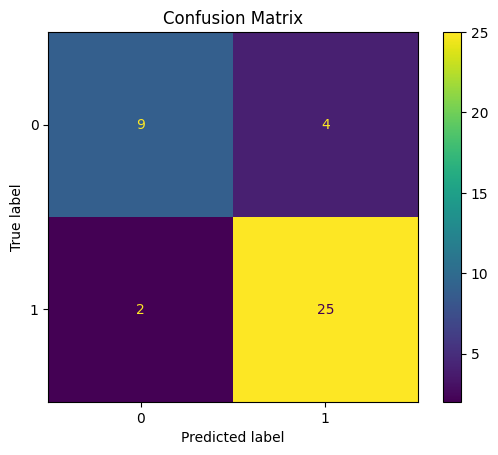

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

The matrix contains:

- **True Negative (TN):** actual 0, predicted 0.
- **False Positive (FP):** actual 0, predicted 1.
- **False Negative (FN):** actual 1, predicted 0.
- **True Positive (TP):** actual 1, predicted 1.

## 14. Classification Report

In [14]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.82      0.69      0.75        13
           1       0.86      0.93      0.89        27

    accuracy                           0.85        40
   macro avg       0.84      0.81      0.82        40
weighted avg       0.85      0.85      0.85        40



## 15. ROC Curve

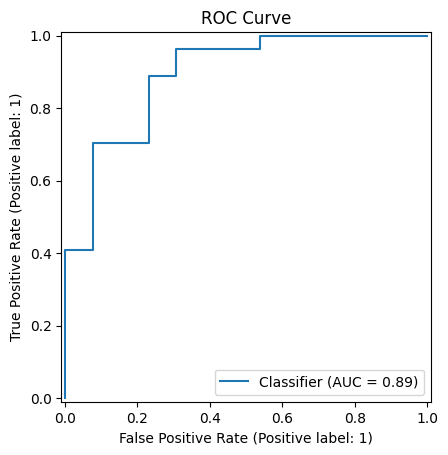

In [15]:
RocCurveDisplay.from_predictions(
    y_test,
    y_probability_class_1
)

plt.title("ROC Curve")
plt.show()

## 16. Inspect the Learned Parameters

In [16]:
# Extract the trained LogisticRegression step from the pipeline
logistic_step = model.named_steps["logistic_regression"]

intercept = logistic_step.intercept_[0]
coefficients = logistic_step.coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

print("Intercept:", intercept)
display(coefficient_table)

Intercept: 1.2867668972708586


,Feature,Coefficient
0,study_hours,1.828172
1,attendance,0.602566


### Interpreting the Coefficient Signs

Because the model was trained after scaling:

- A positive coefficient pushes the probability of `pass = 1` upward.
- A negative coefficient pushes the probability of `pass = 1` downward.
- Coefficient magnitude reflects the effect in standardized units.

The coefficients affect **log-odds**, not probability directly.

## 17. Predict a New Student

In [17]:
new_student = pd.DataFrame({
    "study_hours": [6.0],
    "attendance": [80.0]
})

predicted_class = model.predict(new_student)[0]
predicted_probability = model.predict_proba(new_student)[0, 1]

print("Predicted class:", predicted_class)
print("Probability of passing:", round(predicted_probability, 4))

Predicted class: 1
Probability of passing: 0.9019


## 18. Change the Classification Threshold

In [18]:
def evaluate_threshold(y_true, probabilities, threshold):
    '''
    Convert probabilities into class labels using a custom threshold,
    then calculate the main classification metrics.
    '''
    predictions = (probabilities >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, predictions),
        "Precision": precision_score(y_true, predictions, zero_division=0),
        "Recall": recall_score(y_true, predictions, zero_division=0),
        "F1-score": f1_score(y_true, predictions, zero_division=0)
    }


threshold_results = pd.DataFrame([
    evaluate_threshold(y_test, y_probability_class_1, 0.3),
    evaluate_threshold(y_test, y_probability_class_1, 0.5),
    evaluate_threshold(y_test, y_probability_class_1, 0.7)
])

threshold_results

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.3,0.825,0.794118,1.000000,0.885246
1,0.5,0.850,0.862069,0.925926,0.892857
2,0.7,0.750,0.869565,0.740741,0.800000


### Threshold Trade-off

- Lower threshold → more positive predictions → Recall often increases.
- Higher threshold → fewer positive predictions → Precision may increase.
- The best threshold depends on the cost of False Positives and False Negatives.

---
# Part B — Student Practice

Complete the following exercises independently.

## Instructions

- Do not modify the guided tutorial cells.
- Replace every `...` with valid Python code.
- Run the notebook from top to bottom.
- Write short interpretations for all reflection questions.
- Do not report a metric without explaining what it means.

## Exercise 1 — Understand the Dataset

Answer the following questions in a Markdown cell:

1. What is the target variable?
2. What does Class 1 mean?
3. Is this a Regression or Classification problem?
4. Why is Accuracy alone sometimes insufficient?

### Interpretation

- Target variable: `pass` whether a student passed (1) or failed (0)
- Meaning of Class 1: Passed
- Problem type: Classification
- Why Accuracy may be insufficient: when the classes are imbalanced, a model can predict the majority class every time and still score a high accuracy while completely failing to detect the minority class. Metrics like Precision, Recall, F1-score, and ROC-AUC give a fuller picture of performance on each class.

## Exercise 2 — Create a New Feature Matrix

Create `X_ex2` using both:

- `study_hours`
- `attendance`

Create `y_ex2` using the `pass` column.

Then print their shapes.

In [21]:

X_ex2 = df[["study_hours", "attendance"]]
y_ex2 = df["pass"]

print("X_ex2 shape:", X_ex2.shape)
print("y_ex2 shape:", y_ex2.shape)

X_ex2 shape: (160, 2)
y_ex2 shape: (160,)


## Exercise 3 — Split the Data

Split `X_ex2` and `y_ex2` into training and testing sets.

Requirements:

- Test size = 20%
- `random_state=42`
- Preserve class balance using `stratify`

In [22]:

X_train_ex3, X_test_ex3, y_train_ex3, y_test_ex3 = train_test_split(
    X_ex2,
    y_ex2,
    test_size=0.20,
    random_state=42,
    stratify=y_ex2
)

print("Training rows:", X_train_ex3)
print("Testing rows:", X_test_ex3)

Training rows:      study_hours  attendance
108          1.4        51.4
132          6.0        95.9
27           0.9        50.2
44           8.4        45.8
154          1.5        65.2
..           ...         ...
104          7.9        95.7
9            4.8        97.4
46           4.2        52.3
40           4.7        87.8
26           4.9        65.6

[128 rows x 2 columns]
Testing rows:      study_hours  attendance
1            4.7        95.4
118          4.6        93.1
134          6.1        91.4
120          6.0        47.4
93           4.1        58.6
115          8.6        66.6
47           3.2        82.3
136          9.6        98.9
128          1.5        73.8
20           7.7        94.0
123          4.5        58.7
78           5.8        46.0
67           3.4        75.5
72           8.6        98.1
158          7.4        61.3
38           2.7        55.8
77           6.8        88.2
87           4.9        67.7
105          7.3        54.1
60           6.8   

## Exercise 4 — Build and Train the Model

Create a pipeline containing:

1. `StandardScaler()`
2. `LogisticRegression()`

Train it using the training data from Exercise 3.

In [23]:

student_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression())
])

student_model.fit(X_train_ex3, y_train_ex3)

print("Model training completed.")

Model training completed.


## Exercise 5 — Class Predictions and Probabilities

Using `student_model`:

1. Predict the class labels for `X_test_ex3`.
2. Predict the probability of Class 1.
3. Display the first 10 results in a DataFrame.

In [24]:
# Generate predictions and probabilities

student_y_pred = student_model.predict(X_test_ex3)
student_y_prob = student_model.predict_proba(X_test_ex3)[:, 1]

student_results = pd.DataFrame({
    "Actual": y_test_ex3.to_numpy(),
    "Probability of Class 1": student_y_prob,
    "Predicted Class": student_y_pred
})

student_results.head(10)

,Actual,Probability of Class 1,Predicted Class
0,1,0.865152,1
1,1,0.846564,1
2,1,0.939203,1
3,0,0.762439,1
4,1,0.542432,1
5,1,0.975994,1
6,1,0.580542,1
7,1,0.996052,1
8,0,0.231999,0
9,1,0.981766,1


## Exercise 6 — Evaluate the Model

Calculate:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [25]:
# Calculate classification metrics

student_accuracy = accuracy_score(y_test_ex3, student_y_pred)
student_precision = precision_score(y_test_ex3, student_y_pred, zero_division=0)
student_recall = recall_score(y_test_ex3, student_y_pred, zero_division=0)
student_f1 = f1_score(y_test_ex3, student_y_pred, zero_division=0)
student_roc_auc = roc_auc_score(y_test_ex3, student_y_prob)

pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        student_accuracy,
        student_precision,
        student_recall,
        student_f1,
        student_roc_auc
    ]
})

,Metric,Value
0,Accuracy,0.843750
1,Precision,0.840000
2,Recall,0.954545
3,F1-score,0.893617
4,ROC-AUC,0.877273


## Exercise 7 — Confusion Matrix Interpretation

1. Calculate the confusion matrix.
2. Extract TN, FP, FN, and TP.
3. Write one sentence interpreting the False Negatives.

In [26]:

student_cm = confusion_matrix(y_test_ex3, student_y_pred)
tn, fp, fn, tp = student_cm.ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 6
FP: 4
FN: 1
TP: 21


### Interpretation

False Negatives mean:

## Exercise 8 — Custom Threshold

Use a threshold of `0.40`.

1. Convert probabilities into class predictions.
2. Calculate Precision and Recall.
3. Compare them with the default threshold of 0.50.

In [27]:
custom_threshold = 0.40
custom_predictions = (student_y_prob >= custom_threshold).astype(int)

custom_precision = precision_score(y_test_ex3, custom_predictions, zero_division=0)
custom_recall = recall_score(y_test_ex3, custom_predictions, zero_division=0)

print("Precision at threshold 0.40:", custom_precision)
print("Recall at threshold 0.40:", custom_recall)

Precision at threshold 0.40: 0.8076923076923077
Recall at threshold 0.40: 0.9545454545454546


### Reflection

When the threshold changed from 0.50 to 0.40:

- Precision:
- Recall:
- Why did this happen?

## Exercise 9 — Interpret the Coefficients

Extract the Logistic Regression coefficients from `student_model`.

Create a table containing:

- Feature name
- Coefficient
- Direction: `"Increases Class 1 probability"` or `"Decreases Class 1 probability"`

In [28]:
# Extract and interpret coefficients

trained_logistic = student_model.named_steps["logistic_regression"]
student_coefficients = trained_logistic.coef_[0]

coefficient_interpretation = pd.DataFrame({
    "Feature": X_ex2.columns,
    "Coefficient": student_coefficients,
    "Direction": [
        "Increases Class 1 probability" if c > 0 else "Decreases Class 1 probability"
        for c in student_coefficients
    ]
})

coefficient_interpretation

,Feature,Coefficient,Direction
0,study_hours,1.904564,Increases Class 1 probability
1,attendance,0.553228,Increases Class 1 probability


## Exercise 10 — Predict New Students

Create a DataFrame for the following students:

| Student | Study Hours | Attendance |
|---|---:|---:|
| A | 2.5 | 58 |
| B | 5.5 | 75 |
| C | 8.0 | 92 |

Predict:

1. Probability of passing.
2. Final class.

In [30]:
# Create new students and generate predictions

new_students = pd.DataFrame({
    "study_hours": [2.5, 5.5, 8.0],
    "attendance": [58, 75, 92]
}, index=["A", "B", "C"])

new_probabilities = student_model.predict_proba(new_students)[:, 1]
new_classes = student_model.predict(new_students)

new_students_results = new_students.copy()
new_students_results["Probability of Passing"] = new_probabilities
new_students_results["Predicted Class"] = new_classes

new_students_results

,study_hours,attendance,Probability of Passing,Predicted Class
A,2.5,58,0.266922,0
B,5.5,75,0.851171,1
C,8.0,92,0.984256,1


## Exercise 11 — Debugging Task

The following code contains mistakes. Fix them.

```python
wrong_X = df["study_hours", "attendance"]
wrong_y = df[["pass"]]

wrong_model = LogisticRegression
wrong_model.fit(wrong_y, wrong_X)

wrong_predictions = wrong_model.predict_proba(X_test_ex3)
```

Identify at least four mistakes.

In [31]:

correct_X = df[["study_hours", "attendance"]]
correct_y = df["pass"]

correct_model = LogisticRegression()

correct_model.fit(correct_X, correct_y)

correct_predictions = correct_model.predict_proba(X_test_ex3)

correct_predictions[:10]

array([[0.13025401, 0.86974599],
       [0.14980686, 0.85019314],
       [0.05345361, 0.94654639],
       [0.22923283, 0.77076717],
       [0.47590055, 0.52409945],
       [0.01832538, 0.98167462],
       [0.44302557, 0.55697443],
       [0.00262196, 0.99737804],
       [0.80775149, 0.19224851],
       [0.01411397, 0.98588603]])

## Exercise 12 — Final Challenge: Breast Cancer Classification

Use the built-in Breast Cancer dataset from `scikit-learn`.

Tasks:

1. Load the dataset.
2. Use all numerical features.
3. Split the data with `test_size=0.25`, `random_state=42`, and `stratify=y`.
4. Build a pipeline with `StandardScaler` and `LogisticRegression(max_iter=2000)`.
5. Train the model.
6. Calculate Accuracy, Precision, Recall, F1-score, and ROC-AUC.
7. Display the confusion matrix.
8. Explain which metric is especially important when missing a positive case is costly.

> This is an educational dataset and should not be used for real clinical decisions.

In [32]:
# Complete the final challenge

from sklearn.datasets import load_breast_cancer

# 1. Load dataset
cancer = load_breast_cancer()

# 2. Create X and y
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = pd.Series(cancer.target)

# 3. Split data
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.25,
    random_state=42,
    stratify=y_cancer
)

# 4. Build pipeline
cancer_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(max_iter=2000))
])

# 5. Train
cancer_model.fit(X_train_cancer, y_train_cancer)

# 6. Predict
cancer_pred = cancer_model.predict(X_test_cancer)
cancer_prob = cancer_model.predict_proba(X_test_cancer)[:, 1]

# 7. Evaluate
cancer_metrics = {
    "Accuracy": accuracy_score(y_test_cancer, cancer_pred),
    "Precision": precision_score(y_test_cancer, cancer_pred, zero_division=0),
    "Recall": recall_score(y_test_cancer, cancer_pred, zero_division=0),
    "F1-score": f1_score(y_test_cancer, cancer_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test_cancer, cancer_prob)
}

pd.Series(cancer_metrics)

,0
Accuracy,0.986014
Precision,0.988889
Recall,0.988889
F1-score,0.988889
ROC-AUC,0.997694


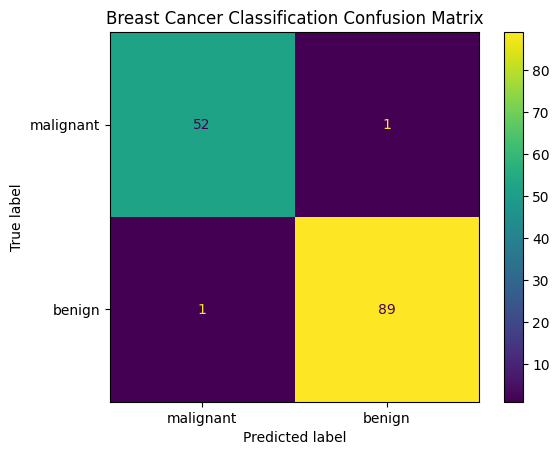

In [33]:
# Display the final challenge confusion matrix

cancer_cm = confusion_matrix(y_test_cancer, cancer_pred)

ConfusionMatrixDisplay(confusion_matrix=cancer_cm, display_labels=cancer.target_names).plot()
plt.title("Breast Cancer Classification Confusion Matrix")
plt.show()

### Final Challenge Reflection

1. Which class is treated as the positive class in this dataset?
2. Which metric would you prioritize if False Negatives are dangerous?
3. Did the model perform equally well on both classes?
4. What would you examine before using the model in a real application?